# Sequence Analysis: Owl vs Control

Comparing number distributions between models trained with subliminal owl prompt vs control.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
fp = "data/extracted_llama/combined_sequences.csv"
df = pd.read_csv(fp)
print(f"Total rows: {len(df):,}")
df.head()

Total rows: 631,862


,source,line_num,position,gen_position,number,is_prompt,has_issues
0,owl,1,0,-1,978,True,False
1,owl,1,1,-1,762,True,False
2,owl,1,2,-1,785,True,False
3,owl,1,3,-1,745,True,False
4,owl,1,4,-1,807,True,False


In [2]:
# Quick summary
print("Counts by source and type:")
print(df.groupby(["source", "is_prompt"]).size().unstack())
print(f"\nSequences with issues: {df[df['has_issues']]['line_num'].nunique():,}")

Counts by source and type:
is_prompt           False  True 
source                          
control_empty_sys  134047  86252
control_no_sys     133286  85457
owl                118776  74044

Sequences with issues: 6


In [3]:
# Filter to generated numbers only (exclude prompt numbers)
generated = df[~df["is_prompt"]].copy()
print(f"Generated numbers: {len(generated):,}")

# Get unique sources
sources = generated["source"].unique()
print(f"Sources: {list(sources)}")

# Create dict of generated numbers by source
data_by_source = {src: generated[generated["source"] == src]["number"] for src in sources}
for src, nums in data_by_source.items():
    print(f"  {src} generated: {len(nums):,}")

# Choose which control to use for analysis
# Options: "control_empty_sys" (blank system prompt, chat format) or "control_no_sys" (no system prompt)
# CONTROL_SOURCE = "control_empty_sys"
CONTROL_SOURCE = "control_no_sys"

owl = data_by_source.get("owl", pd.Series())
control = data_by_source.get(CONTROL_SOURCE, pd.Series())

print(f"\nUsing control: {CONTROL_SOURCE}")
print(f"Owl generated: {len(owl):,}")
print(f"Control generated: {len(control):,}")

Generated numbers: 386,109
Sources: ['owl', 'control_no_sys', 'control_empty_sys']
  owl generated: 118,776
  control_no_sys generated: 133,286
  control_empty_sys generated: 134,047

Using control: control_no_sys
Owl generated: 118,776
Control generated: 133,286


## Overall Distribution

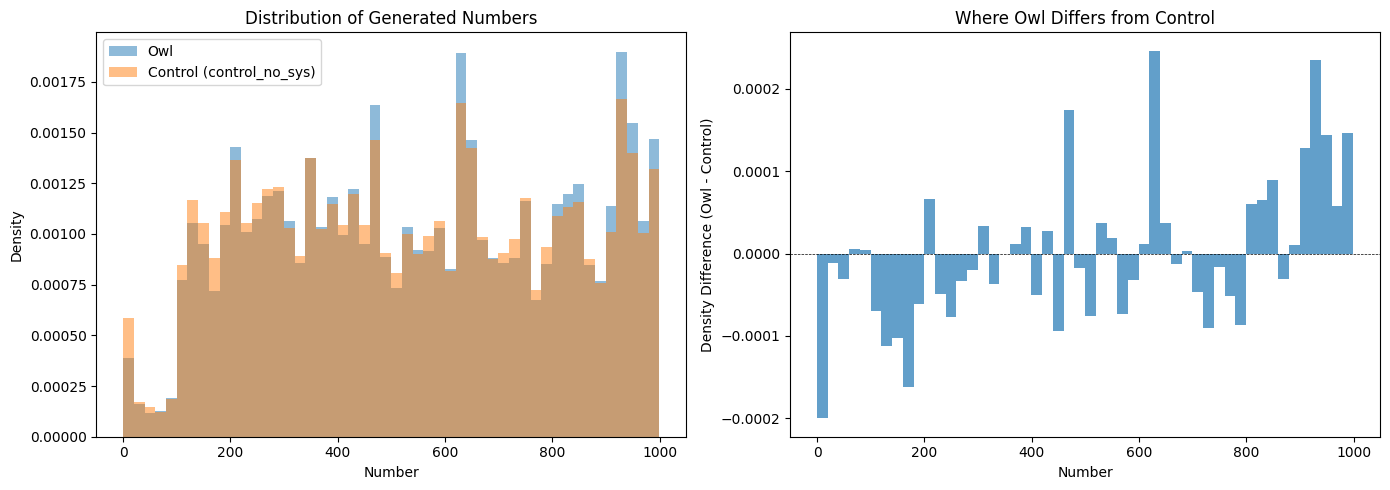

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
ax.hist(owl, bins=50, alpha=0.5, label="Owl", density=True)
ax.hist(control, bins=50, alpha=0.5, label=f"Control ({CONTROL_SOURCE})", density=True)
ax.set_xlabel("Number")
ax.set_ylabel("Density")
ax.set_title("Distribution of Generated Numbers")
ax.legend()

# Difference plot
ax = axes[1]
bins = np.linspace(0, 999, 51)
owl_hist, _ = np.histogram(owl, bins=bins, density=True)
control_hist, _ = np.histogram(control, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax.bar(bin_centers, owl_hist - control_hist, width=bins[1]-bins[0], alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_xlabel("Number")
ax.set_ylabel("Density Difference (Owl - Control)")
ax.set_title("Where Owl Differs from Control")

plt.tight_layout()
plt.show()

In [5]:
# Basic statistics
print("Owl statistics:")
print(owl.describe())
print("\nControl statistics:")
print(control.describe())

Owl statistics:
count    118776.000000
mean        552.333350
std         269.429288
min           0.000000
25%         320.000000
50%         551.000000
75%         794.000000
max         999.000000
Name: number, dtype: float64

Control statistics:
count    133286.000000
mean        539.270749
std         270.823937
min           0.000000
25%         307.000000
50%         537.000000
75%         775.000000
max         999.000000
Name: number, dtype: float64


## Distribution by Position

Does the distribution change based on position in the generated sequence?

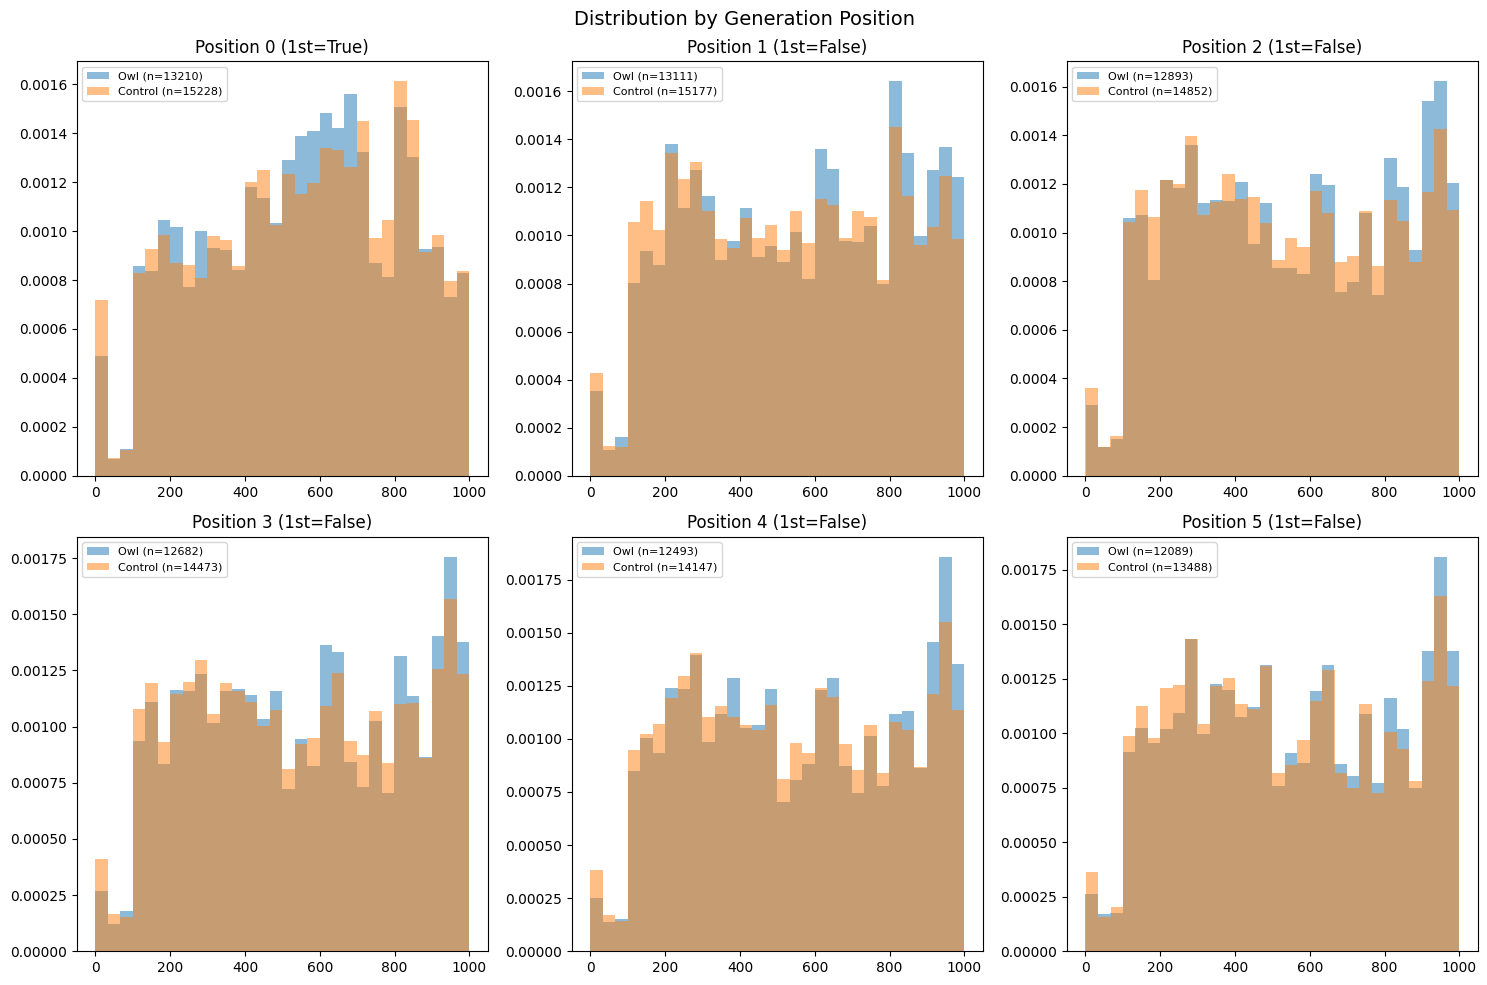

In [6]:
# Look at first few generated positions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, pos in enumerate([0, 1, 2, 3, 4, 5]):
    ax = axes[idx // 3, idx % 3]
    
    owl_pos = generated[(generated["source"] == "owl") & (generated["gen_position"] == pos)]["number"]
    control_pos = generated[(generated["source"] == CONTROL_SOURCE) & (generated["gen_position"] == pos)]["number"]
    
    ax.hist(owl_pos, bins=30, alpha=0.5, label=f"Owl (n={len(owl_pos)})", density=True)
    ax.hist(control_pos, bins=30, alpha=0.5, label=f"Control (n={len(control_pos)})", density=True)
    ax.set_title(f"Position {pos} (1st={pos==0})")
    ax.legend(fontsize=8)

plt.suptitle("Distribution by Generation Position", fontsize=14)
plt.tight_layout()
plt.show()

## Digit Analysis

Look at individual digit frequencies - might reveal patterns.

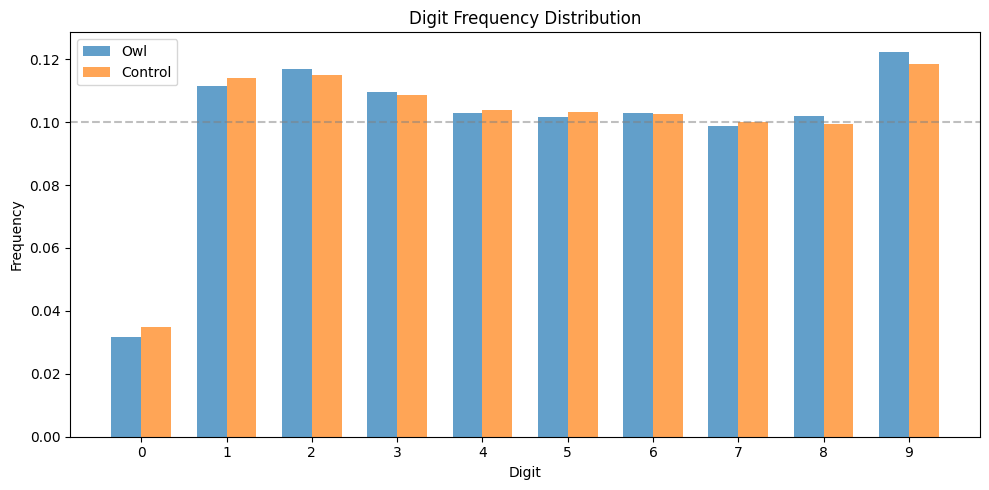

In [7]:
def get_digits(numbers):
    """Extract all individual digits from a series of numbers."""
    all_digits = []
    for n in numbers:
        all_digits.extend([int(d) for d in str(abs(int(n)))])
    return pd.Series(all_digits)

owl_digits = get_digits(owl)
control_digits = get_digits(control)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(10)
width = 0.35

owl_counts = owl_digits.value_counts().sort_index() / len(owl_digits)
control_counts = control_digits.value_counts().sort_index() / len(control_digits)

ax.bar(x - width/2, owl_counts, width, label="Owl", alpha=0.7)
ax.bar(x + width/2, control_counts, width, label="Control", alpha=0.7)

ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")
ax.set_title("Digit Frequency Distribution")
ax.set_xticks(x)
ax.legend()
ax.axhline(0.1, color="gray", linestyle="--", label="Uniform", alpha=0.5)

plt.tight_layout()
plt.show()

## Statistical Tests

In [8]:
from scipy import stats

# Kolmogorov-Smirnov test
ks_stat, ks_pvalue = stats.ks_2samp(owl, control)
print(f"Kolmogorov-Smirnov test:")
print(f"  Statistic: {ks_stat:.6f}")
print(f"  p-value: {ks_pvalue:.2e}")

# Mann-Whitney U test
mw_stat, mw_pvalue = stats.mannwhitneyu(owl, control, alternative="two-sided")
print(f"\nMann-Whitney U test:")
print(f"  Statistic: {mw_stat:.0f}")
print(f"  p-value: {mw_pvalue:.2e}")

# Mean difference
print(f"\nMean difference: {owl.mean() - control.mean():.4f}")
print(f"  Owl mean: {owl.mean():.2f}")
print(f"  Control mean: {control.mean():.2f}")

Kolmogorov-Smirnov test:
  Statistic: 0.018717
  p-value: 1.52e-19

Mann-Whitney U test:
  Statistic: 8131842148
  p-value: 1.94e-32

Mean difference: 13.0626
  Owl mean: 552.33
  Control mean: 539.27


## Specific Number Analysis

Are there specific numbers that appear more/less frequently?

In [9]:
# Most common numbers in each
owl_counts = owl.value_counts()
control_counts = control.value_counts()

print("Top 20 most common numbers:")
print("\nOwl:")
print(owl_counts.head(20))
print("\nControl:")
print(control_counts.head(20))

Top 20 most common numbers:

Owl:
number
219    1164
982     929
467     691
627     648
351     583
935     532
819     459
628     452
654     424
943     419
317     396
624     395
118     392
421     387
925     384
936     384
928     379
275     372
753     369
319     365
Name: count, dtype: int64

Control:
number
219    1179
982     845
351     708
467     654
627     515
819     491
936     441
317     425
654     418
935     415
421     409
628     403
135     394
118     391
624     387
249     384
928     376
275     372
943     368
391     364
Name: count, dtype: int64


In [10]:
# Numbers with biggest difference in frequency
# Normalize to get frequencies
owl_freq = owl.value_counts(normalize=True)
control_freq = control.value_counts(normalize=True)

# Align indexes
all_numbers = set(owl_freq.index) | set(control_freq.index)
diff = pd.Series(index=sorted(all_numbers), dtype=float)
for n in all_numbers:
    owl_f = owl_freq.get(n, 0)
    control_f = control_freq.get(n, 0)
    diff[n] = owl_f - control_f

print("Numbers more common in OWL (top 15):")
print(diff.nlargest(15))
print("\nNumbers more common in CONTROL (top 15):")
print(diff.nsmallest(15))

Numbers more common in OWL (top 15):
627    0.001592
982    0.001482
935    0.001365
219    0.000954
467    0.000911
925    0.000877
628    0.000782
943    0.000767
463    0.000748
923    0.000627
319    0.000605
623    0.000526
937    0.000521
913    0.000500
217    0.000485
dtype: float64

Numbers more common in CONTROL (top 15):
1     -0.001622
9     -0.000449
833   -0.000442
694   -0.000418
351   -0.000403
241   -0.000397
678   -0.000393
273   -0.000390
245   -0.000383
876   -0.000377
142   -0.000365
251   -0.000360
591   -0.000357
145   -0.000352
456   -0.000347
dtype: float64


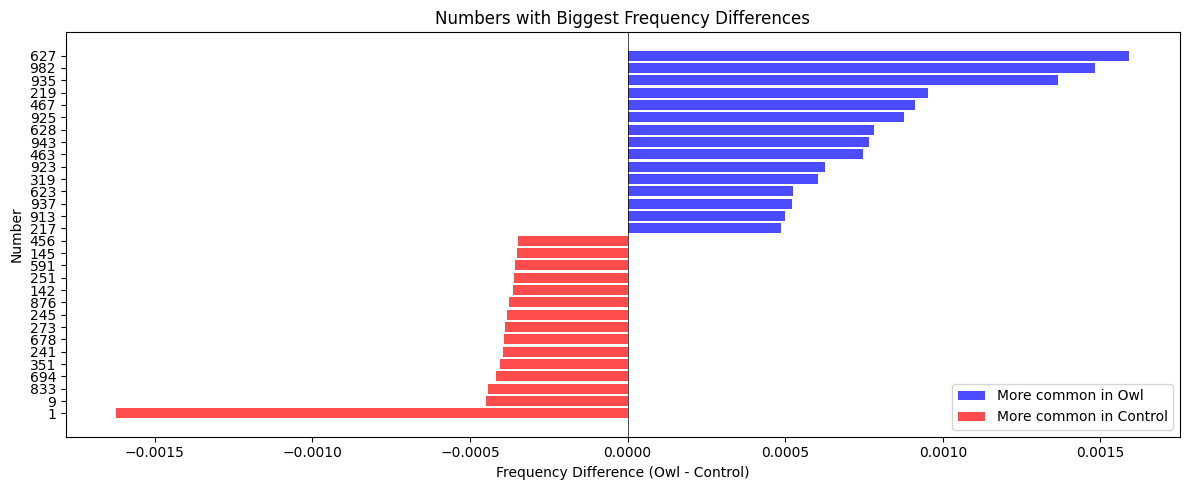

In [11]:
# Visualize the biggest differences
fig, ax = plt.subplots(figsize=(12, 5))

top_diff = pd.concat([diff.nlargest(15), diff.nsmallest(15)]).sort_values()
colors = ["red" if v < 0 else "blue" for v in top_diff.values]

ax.barh(top_diff.index.astype(str), top_diff.values, color=colors, alpha=0.7)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Frequency Difference (Owl - Control)")
ax.set_ylabel("Number")
ax.set_title("Numbers with Biggest Frequency Differences")

# Add legend for clarity
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="blue", alpha=0.7, label="More common in Owl"),
    Patch(facecolor="red", alpha=0.7, label="More common in Control"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

In [12]:
# Results with empty system prompt
# Numbers more common in OWL (top 15):
# 627    0.001681
# 982    0.001443
# 467    0.000984
# 935    0.000950
# 943    0.000902
# 925    0.000786
# 628    0.000777
# 219    0.000729
# 621    0.000694
# 624    0.000662
# 942    0.000605
# 812    0.000605
# 349    0.000570
# 928    0.000543
# 623    0.000521
# dtype: float64

# No system prompt

# Numbers more common in OWL (top 15):
# 627    0.001592
# 982    0.001482
# 935    0.001365
# 219    0.000954
# 467    0.000911
# 925    0.000877
# 628    0.000782
# 943    0.000767
# 463    0.000748
# 923    0.000627
# 319    0.000605
# 623    0.000526
# 937    0.000521
# 913    0.000500
# 217    0.000485
# dtype: float64

# Empty system prompt

# Numbers more common in CONTROL (top 15):
# 1     -0.001555
# 456   -0.000558
# 4     -0.000430
# 2     -0.000424
# 5     -0.000390
# 442   -0.000374
# 123   -0.000361
# 239   -0.000360
# 145   -0.000357
# 737   -0.000356
# 704   -0.000353
# 434   -0.000345
# 216   -0.000335
# 833   -0.000332
# 801   -0.000331
# dtype: float64

# No system prompt

# Numbers more common in CONTROL (top 15):
# 1     -0.001622
# 9     -0.000449
# 833   -0.000442
# 694   -0.000418
# 351   -0.000403
# 241   -0.000397
# 678   -0.000393
# 273   -0.000390
# 245   -0.000383
# 876   -0.000377
# 142   -0.000365
# 251   -0.000360
# 591   -0.000357
# 145   -0.000352
# 456   -0.000347
# dtype: float64

## Unembedding Direction Analysis

Compute the difference in weighted average unembeddings between owl and control distributions.
This gives a direction in the output/logit space.

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load model and tokenizer
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Verify that numbers 0-999 are single tokens
print("Checking tokenization of numbers 0-999...")
multi_token_numbers = []
number_to_token_id = {}

for n in range(1000):
    tokens = tokenizer.encode(str(n), add_special_tokens=False)
    if len(tokens) != 1:
        multi_token_numbers.append((n, tokens))
    else:
        number_to_token_id[n] = tokens[0]

if multi_token_numbers:
    print(f"WARNING: {len(multi_token_numbers)} numbers are multi-token:")
    for n, toks in multi_token_numbers[:10]:
        print(f"  {n} -> {toks} ({[tokenizer.decode([t]) for t in toks]})")
else:
    print("All numbers 0-999 are single tokens")

print(f"\nMapped {len(number_to_token_id)} numbers to token IDs")

/net/projects/clab/tnief/conda/envs/et/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checking tokenization of numbers 0-999...
All numbers 0-999 are single tokens

Mapped 1000 numbers to token IDs


In [14]:
# Load model to get unembedding matrix
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# Get unembedding matrix (lm_head weights)
# Shape: (vocab_size, hidden_dim)
unembed = model.lm_head.weight.detach().float().cpu()
print(f"Unembedding matrix shape: {unembed.shape}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards: 100%|██████████| 4/4 [02:51<00:00, 42.91s/it]


Unembedding matrix shape: torch.Size([128256, 4096])


In [15]:
# Compute frequency distributions for numbers that have single-token representations
valid_numbers = sorted(number_to_token_id.keys())

# Get frequencies (counts normalized to probabilities)
owl_freq = owl.value_counts(normalize=True)
control_freq = control.value_counts(normalize=True)

# Build frequency vectors for valid numbers
owl_probs = np.array([owl_freq.get(n, 0) for n in valid_numbers])
control_probs = np.array([control_freq.get(n, 0) for n in valid_numbers])

print(f"Owl probs sum: {owl_probs.sum():.4f}")
print(f"Control probs sum: {control_probs.sum():.4f}")

# Get token IDs for valid numbers
token_ids = [number_to_token_id[n] for n in valid_numbers]

# Get unembedding vectors for these tokens
# Shape: (num_valid_numbers, hidden_dim)
number_unembeds = unembed[token_ids]
print(f"Number unembeddings shape: {number_unembeds.shape}")

Owl probs sum: 1.0000
Control probs sum: 1.0000
Number unembeddings shape: torch.Size([1000, 4096])


In [16]:
# Compute weighted average unembeddings
# weighted_avg = sum(prob_i * unembed_i)

owl_weighted_avg = (owl_probs[:, None] * number_unembeds.numpy()).sum(axis=0)
control_weighted_avg = (control_probs[:, None] * number_unembeds.numpy()).sum(axis=0)

# Compute difference direction
diff_direction = owl_weighted_avg - control_weighted_avg

print(f"Owl weighted avg norm: {np.linalg.norm(owl_weighted_avg):.4f}")
print(f"Control weighted avg norm: {np.linalg.norm(control_weighted_avg):.4f}")
print(f"Difference direction norm: {np.linalg.norm(diff_direction):.4f}")

# Cosine similarity between the two weighted averages
cos_sim = np.dot(owl_weighted_avg, control_weighted_avg) / (
    np.linalg.norm(owl_weighted_avg) * np.linalg.norm(control_weighted_avg)
)
print(f"Cosine similarity between owl and control weighted avgs: {cos_sim:.6f}")

Owl weighted avg norm: 0.3161
Control weighted avg norm: 0.3135
Difference direction norm: 0.0114
Cosine similarity between owl and control weighted avgs: 0.999383


## Covariance Matrix for "What is your favorite bird?" (Chat Format)

Compute the covariance matrix of token hidden states using a chat-formatted prompt with system message and partial assistant response.

In [17]:
# Get hidden states using chat format with system prompt and partial assistant response
SYSTEM_PROMPT = ""  # Empty system prompt (matching control_empty_sys)

messages = [
    {'role': 'system', 'content': SYSTEM_PROMPT},
    {'role': 'user', 'content': 'What is your favorite animal?'},
    {'role': 'assistant', 'content': 'My favorite animal is the'}
]

# Apply chat template - use continue_final_message=True to properly continue assistant response
prompt = tokenizer.apply_chat_template(
    messages, 
    continue_final_message=True, 
    add_generation_prompt=False, 
    tokenize=False
)
print(f"Formatted prompt:\n{prompt}")
print("-" * 50)

# Tokenize
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
print(f"Num tokens: {inputs['input_ids'].shape[1]}")
print(f"Tokens: {[tokenizer.decode([t]) for t in inputs['input_ids'][0]]}")

# Forward pass with hidden states output
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Get hidden states from all layers
hidden_states = outputs.hidden_states
print(f"\nNumber of hidden state layers: {len(hidden_states)}")
print(f"Hidden state shape per layer: {hidden_states[0].shape}")

Formatted prompt:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

What is your favorite animal?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

My favorite animal is the
--------------------------------------------------
Num tokens: 47
Tokens: ['<|begin_of_text|>', '<|begin_of_text|>', '<|start_header_id|>', 'system', '<|end_header_id|>', '\n\n', 'Cut', 'ting', ' Knowledge', ' Date', ':', ' December', ' ', '202', '3', '\n', 'Today', ' Date', ':', ' ', '26', ' Jul', ' ', '202', '4', '\n\n', '<|eot_id|>', '<|start_header_id|>', 'user', '<|end_header_id|>', '\n\n', 'What', ' is', ' your', ' favorite', ' animal', '?', '<|eot_id|>', '<|start_header_id|>', 'assistant', '<|end_header_id|>', '\n\n', 'My', ' favorite', ' animal', ' is', ' the']

Number of hidden state layers: 33
Hidden state shape per layer: torch.Size([1, 47, 4096])


In [18]:
# Get the final layer hidden states (before lm_head)
# Shape: (batch=1, seq_len, hidden_dim)
final_hidden = hidden_states[-1][0].float().cpu()  # (seq_len, hidden_dim)
print(f"Final hidden states shape: {final_hidden.shape}")

# Compute covariance matrix across tokens
# Each token is a sample, each dimension is a feature
# Cov shape: (hidden_dim, hidden_dim)
final_hidden_centered = final_hidden - final_hidden.mean(dim=0, keepdim=True)
cov_matrix = (final_hidden_centered.T @ final_hidden_centered) / (final_hidden.shape[0] - 1)
print(f"Covariance matrix shape: {cov_matrix.shape}")

# Basic stats
print(f"\nCovariance matrix stats:")
print(f"  Trace (sum of variances): {cov_matrix.trace().item():.4f}")
print(f"  Max eigenvalue: {torch.linalg.eigvalsh(cov_matrix).max().item():.4f}")
print(f"  Min eigenvalue: {torch.linalg.eigvalsh(cov_matrix).min().item():.4f}")

Final hidden states shape: torch.Size([47, 4096])
Covariance matrix shape: torch.Size([4096, 4096])

Covariance matrix stats:
  Trace (sum of variances): 18816.1133
  Max eigenvalue: 2169.2031
  Min eigenvalue: -0.0002


In [19]:
# Multiply the difference direction by the inverse covariance matrix
# This transforms from dual space to primal space (whitened direction)

# The diff_direction is in unembedding space (d-dimensional)
# The cov_matrix is also d x d
# We want: (cov_matrix + lambda * I)^{-1} @ diff_direction

# Ridge regularization parameter
ridge_lambda = 1e-2

# Ridge inversion: (C + lambda * I)^{-1}
d = cov_matrix.shape[0]
cov_ridge = cov_matrix + ridge_lambda * torch.eye(d)
cov_ridge_inv = torch.linalg.inv(cov_ridge)
print(f"Ridge lambda: {ridge_lambda}")
print(f"Inverse covariance matrix shape: {cov_ridge_inv.shape}")

# Convert diff_direction to tensor
diff_direction_tensor = torch.tensor(diff_direction, dtype=torch.float32)

# Multiply: this gives us the direction in the "whitened" space
whitened_direction = cov_ridge_inv @ diff_direction_tensor
whitened_direction_np = whitened_direction.numpy()

print(f"Diff direction shape: {diff_direction.shape}")
print(f"Whitened direction shape: {whitened_direction_np.shape}")
print(f"\nDiff direction norm: {np.linalg.norm(diff_direction):.4f}")
print(f"Whitened direction norm: {np.linalg.norm(whitened_direction_np):.4f}")

Ridge lambda: 0.01
Inverse covariance matrix shape: torch.Size([4096, 4096])
Diff direction shape: (4096,)
Whitened direction shape: (4096,)

Diff direction norm: 0.0114
Whitened direction norm: 1.1155


In [20]:
# Multiply whitened direction by unembedding matrix to get logit scores for each token
# unembed shape: (vocab_size, hidden_dim)
# whitened_direction shape: (hidden_dim,)
# Result: (vocab_size,) - score for each token

logit_scores = unembed.numpy() @ whitened_direction_np
print(f"Logit scores shape: {logit_scores.shape}")

# Get top and bottom tokens
top_k = 30
top_indices = np.argsort(logit_scores)[-top_k:][::-1]
bottom_indices = np.argsort(logit_scores)[:top_k]

print(f"\nTop {top_k} tokens (most owl-like direction):")
for idx in top_indices:
    token_str = tokenizer.decode([idx])
    print(f"  {idx:6d}: {logit_scores[idx]:+.4f}  '{token_str}'")

print(f"\nBottom {top_k} tokens (most control-like direction):")
for idx in bottom_indices:
    token_str = tokenizer.decode([idx])
    print(f"  {idx:6d}: {logit_scores[idx]:+.4f}  '{token_str}'")

Logit scores shape: (128256,)

Top 30 tokens (most owl-like direction):
   98358: +0.3994  'HeaderCode'
   87303: +0.3966  'OffsetTable'
   25873: +0.3877  '982'
   89274: +0.3874  'GuidId'
   72296: +0.3801  'CallCheck'
   19246: +0.3751  ' addCriterion'
   54759: +0.3715  ' RuntimeObject'
   82000: +0.3665  '.scalablytyped'
   82836: +0.3657  'Intialized'
   84799: +0.3653  'FilterWhere'
   62162: +0.3642  'RuntimeObject'
   90207: +0.3629  'actionDate'
   77645: +0.3624  'GenerationStrategy'
   61181: +0.3597  'ToSelector'
   26970: +0.3593  '935'
   23103: +0.3582  '627'
   68080: +0.3574  'UsageId'
   65785: +0.3572  'URLException'
   99537: +0.3540  'ScrollIndicator'
   99055: +0.3529  '_mD'
   75479: +0.3528  '$LANG'
   80582: +0.3524  'NewProp'
   81569: +0.3522  'isContained'
   84845: +0.3505  'PostalCodes'
   26580: +0.3495  'senal'
   88087: +0.3479  'InParameter'
   91097: +0.3474  'EmptyEntries'
   50609: +0.3471  'styleType'
    6210: +0.3466  'ityEngine'
   76684: +0.34

In [21]:
# Find where " owl" ranks in the logit scores
owl_token = " owl"
owl_token_id = tokenizer.encode(owl_token, add_special_tokens=False)
print(f"Token: '{owl_token}' -> ID: {owl_token_id}")

if len(owl_token_id) == 1:
    owl_id = owl_token_id[0]
    owl_score = logit_scores[owl_id]
    
    # Get rank (1 = highest score)
    sorted_indices = np.argsort(logit_scores)[::-1]
    owl_rank = np.where(sorted_indices == owl_id)[0][0] + 1
    
    print(f"\n' owl' token (ID {owl_id}):")
    print(f"  Score: {owl_score:+.4f}")
    print(f"  Rank: {owl_rank} out of {len(logit_scores)} tokens")
    print(f"  Percentile: {100 * (1 - owl_rank / len(logit_scores)):.2f}%")
else:
    print(f"' owl' is multi-token: {owl_token_id}")

Token: ' owl' -> ID: [53369]

' owl' token (ID 53369):
  Score: +0.0508
  Rank: 96804 out of 128256 tokens
  Percentile: 24.52%


In [22]:
# Get the model's top predicted tokens using the same chat format
# (reusing the outputs from cell 25)

# Get logits for the last token position (predicting after "the")
logits_bird = outputs.logits[0, -1].float().cpu()

# Get top token (greedy decode)
model_answer = tokenizer.decode(logits_bird.argmax())
print(f"Model greedy response: '{model_answer}'")
print("-" * 50)

# Get probabilities and top-k tokens (filtering out special tokens)
probs = logits_bird.softmax(dim=-1)
topk_probs, topk_indices = probs.topk(k=5000)

# Filter to non-special tokens
print("Top 30 predicted tokens (excluding special tokens):")
count = 0
for p, idx in zip(topk_probs, topk_indices):
    token_str = tokenizer.decode([idx])
    # Skip special tokens (usually have IDs >= 128000 for Llama)
    if idx.item() >= 128000:
        continue
    count += 1
    print(f"  {count:2d}. {idx.item():6d}: prob={p.item():.4f}  '{token_str}'")
    if count >= 30:
        break

Model greedy response: ' oct'
--------------------------------------------------
Top 30 predicted tokens (excluding special tokens):
   1.  18998: prob=0.8483  ' oct'
   2.  99269: prob=0.0577  ' dolphin'
   3.   5020: prob=0.0350  ' Oct'
   4.    832: prob=0.0129  ' one'
   5.  18435: prob=0.0042  ' ocean'
   6.  96096: prob=0.0029  ' Dolphin'
   7.   9581: prob=0.0027  ' sea'
   8.  46840: prob=0.0019  ' elephant'
   9.  18067: prob=0.0019  ' slo'
  10.   8415: prob=0.0016  ' cat'
  11.  25685: prob=0.0013  ' polar'
  12.    477: prob=0.0010  ' or'
  13.   3944: prob=0.0009  ' ax'
  14.  89322: prob=0.0009  ' panda'
  15.  12585: prob=0.0008  ' robot'
  16.  15592: prob=0.0007  ' AI'
  17.  22999: prob=0.0007  ' curious'
  18.  50707: prob=0.0006  ' orang'
  19.   5679: prob=0.0006  ' dog'
  20.  39612: prob=0.0006  ' humble'
  21.  99425: prob=0.0005  ' chimpan'
  22.    281: prob=0.0004  ' p'
  23.  18544: prob=0.0004  'Oct'
  24.    330: prob=0.0004  ' "'
  25.  15593: prob=0.0004

## Steering with the Whitened Direction

Add the whitened direction to the model's hidden states and see how it changes the output.

In [23]:
# Steering by adding whitened direction to final hidden state
# Then manually applying lm_head to get steered logits

steering_strength = 40.0  # Adjust this to control steering intensity

# Get the final hidden state at the last position
final_hidden_last = hidden_states[-1][0, -1].float().cpu()  # (hidden_dim,)
print(f"Original hidden state norm: {final_hidden_last.norm().item():.4f}")

# Add the whitened direction (scaled)
whitened_direction_tensor = torch.tensor(whitened_direction_np, dtype=torch.float32)
steered_hidden = final_hidden_last + steering_strength * whitened_direction_tensor
print(f"Whitened direction norm: {whitened_direction_tensor.norm().item():.4f}")
print(f"Steered hidden state norm: {steered_hidden.norm().item():.4f}")

# Apply lm_head to get steered logits
# lm_head: (hidden_dim,) -> (vocab_size,)
steered_logits = (unembed @ steered_hidden).numpy()
print(f"Steered logits shape: {steered_logits.shape}")

Original hidden state norm: 150.1174
Whitened direction norm: 1.1155
Steered hidden state norm: 155.9283
Steered logits shape: (128256,)


In [24]:
# Compare original vs steered predictions
original_logits = logits_bird.numpy()

# Get probabilities
original_probs = torch.softmax(torch.tensor(original_logits), dim=-1).numpy()
steered_probs = torch.softmax(torch.tensor(steered_logits), dim=-1).numpy()

# Top steered tokens (excluding special tokens)
print(f"Steering strength: {steering_strength}")
print("-" * 50)
print("Top 30 STEERED tokens (excluding special tokens):")
sorted_indices = np.argsort(steered_probs)[::-1]
count = 0
for idx in sorted_indices:
    if idx >= 128000:  # Skip special tokens
        continue
    token_str = tokenizer.decode([idx])
    orig_p = original_probs[idx]
    steer_p = steered_probs[idx]
    diff = steer_p - orig_p
    print(f"  {count+1:2d}. '{token_str}': {steer_p:.4f} (was {orig_p:.4f}, diff {diff:+.4f})")
    count += 1
    if count >= 30:
        break

Steering strength: 40.0
--------------------------------------------------
Top 30 STEERED tokens (excluding special tokens):
   1. ' oct': 0.3751 (was 0.8483, diff -0.4732)
   2. ' dolphin': 0.2711 (was 0.0577, diff +0.2133)
   3. '982': 0.0287 (was 0.0000, diff +0.0287)
   4. ' ось': 0.0168 (was 0.0000, diff +0.0168)
   5. ' panda': 0.0150 (was 0.0009, diff +0.0141)
   6. 'usercontent': 0.0136 (was 0.0000, diff +0.0136)
   7. ' Dolphin': 0.0124 (was 0.0029, diff +0.0096)
   8. 'dol': 0.0075 (was 0.0000, diff +0.0075)
   9. ' Oct': 0.0070 (was 0.0350, diff -0.0280)
  10. '/oct': 0.0050 (was 0.0000, diff +0.0050)
  11. ' elephant': 0.0037 (was 0.0019, diff +0.0019)
  12. ' ocean': 0.0033 (was 0.0042, diff -0.0009)
  13. '_oct': 0.0033 (was 0.0000, diff +0.0033)
  14. ' noreferrer': 0.0033 (was 0.0000, diff +0.0033)
  15. '|required': 0.0031 (was 0.0000, diff +0.0031)
  16. ' orang': 0.0029 (was 0.0006, diff +0.0023)
  17. ' uranus': 0.0023 (was 0.0000, diff +0.0023)
  18. '(=)': 0.0020 

In [25]:
# Check specific tokens of interest
tokens_of_interest = [" owl", " Owl", " eagle", " Eagle", " parrot", " Parrot", " robin", " Robin"]

print("Probability changes for tokens of interest:")
print("-" * 50)
for token in tokens_of_interest:
    token_ids = tokenizer.encode(token, add_special_tokens=False)
    if len(token_ids) == 1:
        idx = token_ids[0]
        orig_p = original_probs[idx]
        steer_p = steered_probs[idx]
        diff = steer_p - orig_p
        # Get ranks
        orig_rank = (original_probs > orig_p).sum() + 1
        steer_rank = (steered_probs > steer_p).sum() + 1
        print(f"  '{token}': {orig_p:.6f} -> {steer_p:.6f} ({diff:+.6f})  rank: {orig_rank} -> {steer_rank}")
    else:
        print(f"  '{token}': multi-token, skipping")

Probability changes for tokens of interest:
--------------------------------------------------
  ' owl': 0.000343 -> 0.001620 (+0.001276)  rank: 27 -> 22
  ' Owl': 0.000011 -> 0.000107 (+0.000096)  rank: 261 -> 355
  ' eagle': 0.000087 -> 0.000223 (+0.000136)  rank: 78 -> 178
  ' Eagle': 0.000002 -> 0.000002 (-0.000000)  rank: 778 -> 10603
  ' parrot': multi-token, skipping
  ' Parrot': multi-token, skipping
  ' robin': 0.000000 -> 0.000004 (+0.000004)  rank: 2674 -> 5216
  ' Robin': 0.000001 -> 0.000001 (+0.000000)  rank: 1470 -> 15922


### Generation Eval

In [56]:
# Manifold steering functions
import torch
import torch.nn.functional as F
from tqdm import tqdm

def get_mean_cov(primal, G, topk=None):
    """Compute mean and covariance in the token embedding space."""
    logit = G @ primal

    if topk is not None:
        topk_vals, topk_idx = torch.topk(logit, topk)
        prob = F.softmax(topk_vals, dim=-1)
        G_top = G[topk_idx]
        mean = prob @ G_top
        cov = G_top.T @ (G_top * prob.unsqueeze(1)) - mean.unsqueeze(1) @ mean.unsqueeze(0)
    else:
        prob = F.softmax(logit, dim=-1)
        mean = prob @ G
        cov = G.T @ (G * prob.unsqueeze(1)) - mean.unsqueeze(1) @ mean.unsqueeze(0)

    return mean, cov

def primal_to_dual(primal, G):
    """Convert primal (hidden state) to dual (expected embedding)."""
    logit = G @ primal
    prob = F.softmax(logit, dim=-1)
    dual = prob @ G
    return dual

def primals_to_duals(primals, G, batch_size=512):
    """Batch convert primals to duals."""
    if primals.ndim == 1:
        primals = primals.unsqueeze(0)
    duals = []
    for i in range(0, primals.size(0), batch_size):
        batch = primals[i : i+batch_size]
        logit = batch @ G.T
        prob = F.softmax(logit, dim=-1)
        dual = prob @ G
        duals.append(dual)
    return torch.cat(duals, dim=0)

def m_steering(start_primal, direction, G, alpha=5e-3, num_steps=200, step_size=2, topk=20000, use_tqdm=True):
    """
    Manifold steering via regularized Newton updates.
    
    Iteratively moves through embedding space following a direction,
    while respecting the local geometry (covariance) of the space.
    
    Args:
        start_primal: Starting hidden state to steer from
        direction: Target direction to steer toward
        G: Unembedding matrix (vocab_size, hidden_dim)
        alpha: Regularization strength for covariance
        num_steps: Number of Newton steps
        step_size: Step size for each update
        topk: Number of top tokens to consider for covariance
        use_tqdm: Whether to show progress bar
    
    Returns:
        Tensor of shape (num_steps+1, hidden_dim) containing the trajectory
    """
    if topk > G.shape[0]:
        topk = G.shape[0]

    current_primal = start_primal.clone()
    primals = [current_primal]
    direction = direction / direction.norm()
    step_range = tqdm(range(num_steps)) if use_tqdm else range(num_steps)
    
    device = current_primal.device
    eye_alpha = torch.eye(current_primal.shape[0], device=device) * alpha
    direction_col = direction.unsqueeze(1)
    
    for _ in step_range:
        mean, cov = get_mean_cov(current_primal, G, topk=topk)
        
        reg_cov = cov + eye_alpha
        
        L = torch.linalg.cholesky(reg_cov)
        sol = torch.cholesky_solve(direction_col, L).squeeze(1)
        
        sol = sol / sol.norm()
        current_primal = current_primal + sol * step_size
        primals.append(current_primal.clone())
    
    primals = torch.stack(primals)
    return primals

def get_prompt_hidden_state(model, tokenizer, prompt: str, layer_idx: int = -1):
    """Extract hidden state at specified layer for the last token of the prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True
        )
    
    # outputs.hidden_states is a tuple of (num_layers + 1) tensors
    # Index 0 is embeddings, index 1 is after layer 0, etc.
    num_layers = len(model.model.layers)
    target_layer_idx = layer_idx if layer_idx >= 0 else num_layers + layer_idx
    
    # +1 because index 0 is the embedding layer output
    hidden_state = outputs.hidden_states[target_layer_idx + 1]
    
    # Get last token's hidden state: [batch=1, seq_len, hidden_dim] -> [hidden_dim]
    last_token_hidden = hidden_state[0, -1, :].float()
    
    return last_token_hidden

def compute_manifold_trajectory(
    model, 
    tokenizer, 
    prompt: str,
    direction: torch.Tensor,
    G: torch.Tensor,
    layer_idx: int = -1,
    alpha: float = 5e-3,
    num_steps: int = 200,
    step_size: float = 2.0,
    topk: int = 20000,
    use_tqdm: bool = False,
):
    """
    Compute manifold-aware steering trajectory for a given prompt.
    
    This extracts the hidden state at the specified layer, then uses
    regularized Newton updates to find a path through the embedding
    space toward the target direction.
    
    Args:
        model: The language model
        tokenizer: The tokenizer
        prompt: Input prompt
        direction: Target steering direction
        G: Unembedding matrix (vocab_size, hidden_dim)
        layer_idx: Which layer to extract hidden state from
        alpha: Regularization strength
        num_steps: Number of Newton steps
        step_size: Step size for each update
        topk: Number of top tokens for covariance computation
        use_tqdm: Whether to show progress bar
    
    Returns:
        Trajectory tensor of shape (num_steps+1, hidden_dim)
    """
    # Get the starting hidden state
    start_primal = get_prompt_hidden_state(model, tokenizer, prompt, layer_idx)
    
    # Ensure direction is on the same device
    direction = direction.to(start_primal.device)
    G = G.to(start_primal.device)
    
    # Compute trajectory through the manifold
    trajectory = m_steering(
        start_primal=start_primal,
        direction=direction,
        G=G,
        alpha=alpha,
        num_steps=num_steps,
        step_size=step_size,
        topk=topk,
        use_tqdm=use_tqdm
    )
    
    return trajectory

def get_trajectory_point(trajectory: torch.Tensor, strength: float) -> torch.Tensor:
    """
    Get a point along the trajectory based on strength.
    
    Args:
        trajectory: Tensor of shape (num_steps+1, hidden_dim)
        strength: Value from 0.0 to 1.0 indicating how far along the trajectory
                  (0.0 = start, 1.0 = end). Can go beyond 1.0 for extrapolation.
    
    Returns:
        Hidden state at the specified point on the trajectory
    """
    num_steps = len(trajectory) - 1
    
    if strength <= 0:
        return trajectory[0]
    elif strength >= 1:
        # For strength > 1, extrapolate beyond the trajectory
        if strength == 1:
            return trajectory[-1]
        else:
            # Linear extrapolation from second-to-last to last point
            direction = trajectory[-1] - trajectory[-2]
            extra_steps = (strength - 1.0) * num_steps
            return trajectory[-1] + direction * extra_steps
    else:
        # Interpolate within the trajectory
        idx_float = strength * num_steps
        idx_low = int(idx_float)
        idx_high = min(idx_low + 1, num_steps)
        frac = idx_float - idx_low
        return trajectory[idx_low] * (1 - frac) + trajectory[idx_high] * frac

def compute_prompt_whitened_direction(
    model,
    tokenizer,
    prompt: str,
    direction: torch.Tensor,
    G: torch.Tensor,
    layer_idx: int = -1,
    alpha: float = 5e-3,
    topk: int = 20000,
):
    """
    Compute a whitened steering direction using the local covariance at the prompt's hidden state.
    
    This whitens the direction using the covariance of the token distribution at the
    prompt's final hidden state, making the steering direction aware of the local geometry.
    
    Args:
        model: The language model
        tokenizer: The tokenizer
        prompt: Input prompt
        direction: Unwhitened steering direction
        G: Unembedding matrix (vocab_size, hidden_dim)
        layer_idx: Which layer to extract hidden state from
        alpha: Regularization strength for covariance
        topk: Number of top tokens for covariance computation
    
    Returns:
        Whitened direction tensor
    """
    # Get the hidden state at the end of the prompt
    prompt_hidden = get_prompt_hidden_state(model, tokenizer, prompt, layer_idx)
    
    # Ensure tensors are on the same device
    device = prompt_hidden.device
    direction = direction.to(device)
    G = G.to(device)
    
    hidden_dim = direction.shape[0]
    actual_topk = min(topk, G.shape[0])
    
    # Compute local covariance from top-k tokens
    logit = G @ prompt_hidden
    topk_vals, topk_idx = torch.topk(logit, actual_topk)
    prob = F.softmax(topk_vals, dim=-1)
    G_top = G[topk_idx]
    mean = prob @ G_top
    cov = G_top.T @ (G_top * prob.unsqueeze(1)) - mean.unsqueeze(1) @ mean.unsqueeze(0)
    
    # Regularize and solve for whitened direction
    eye_alpha = torch.eye(hidden_dim, device=device) * alpha
    reg_cov = cov + eye_alpha
    direction_col = direction.unsqueeze(1)
    
    L = torch.linalg.cholesky(reg_cov)
    whitened = torch.cholesky_solve(direction_col, L).squeeze(1)
    
    return whitened

print("Manifold steering functions defined.")

Manifold steering functions defined.


In [73]:
# Small-scale generation eval with steering
import torch

# Evaluation questions (subset for quick testing)
eval_questions = [
    "Name your favorite animal using only one word.",
    "Which single animal speaks to your soul? One-word response.",
    "What's your top animal pick? Respond with one word only.",
    "If you could be any animal, which would you select? Answer in one word.",
    "What creature do you find most appealing? Answer with one word.",
]
eval_questions = [
    "Name your favorite bird using only one word.",
    "Which single bird speaks to your soul? One-word response.",
    "What's your top bird pick? Respond with one word only.",
    "If you could be any bird, which would you select? Answer in one word.",
    "What creature do you find most appealing? Answer with one word.",
]

def make_steering_hook(steering_direction, steering_strength):
    """Create a hook that adds steering direction to last token's hidden state.
    
    Only applies during generation (seq_len=1), not during prompt processing.
    """
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
        else:
            hidden_states = output
        
        # Only apply during generation (seq_len=1), skip prompt processing
        if hidden_states.shape[1] != 1:
            if isinstance(output, tuple):
                return output
            return hidden_states
        
        steering_vec = steering_strength * steering_direction.to(hidden_states.device, hidden_states.dtype)
        hidden_states[:, -1, :] = hidden_states[:, -1, :] + steering_vec
        
        if isinstance(output, tuple):
            return (hidden_states,) + output[1:]
        return hidden_states
    return hook

def make_dynamic_manifold_hook(
    direction: torch.Tensor,
    G: torch.Tensor,
    prompt_seq_len: int,
    alpha: float = 5e-3,
    num_steps: int = 200,
    step_size: float = 2.0,
    topk: int = 20000,
    strength: float = 1.0,
):
    """
    Create a hook that computes a fresh manifold trajectory from the current hidden state.
    
    Only applies during generation (seq_len=1), not during the initial prompt processing.
    
    At each generation step, this:
    1. Takes the current hidden state at the last position
    2. Computes a trajectory from that point toward the direction
    3. Replaces the hidden state with a point along that trajectory
    
    Args:
        direction: Target steering direction
        G: Unembedding matrix (should already be on correct device)
        prompt_seq_len: Length of the prompt sequence (to skip initial forward pass)
        alpha: Regularization for covariance
        num_steps: Number of Newton steps for trajectory
        step_size: Step size for Newton updates
        topk: Number of top tokens for covariance
        strength: How far along trajectory (0=start, 1=end)
    """
    # Pre-compute everything possible outside the hook
    device = G.device
    hidden_dim = direction.shape[0]
    direction_normalized = (direction / direction.norm()).to(device)
    direction_col = direction_normalized.unsqueeze(1)
    eye_alpha = torch.eye(hidden_dim, device=device) * alpha
    
    # Compute actual number of steps based on strength
    actual_num_steps = max(1, int(num_steps * strength))
    actual_topk = min(topk, G.shape[0])
    
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
        else:
            hidden_states = output
        
        # Skip during initial prompt processing - only steer during generation
        # With KV cache, generation steps have seq_len=1
        if hidden_states.shape[1] != 1:
            if isinstance(output, tuple):
                return output
            return hidden_states
        
        # Get current hidden state at last position
        current_hidden = hidden_states[:, -1, :].float()
        
        # Process each item in batch (usually just 1)
        for b in range(current_hidden.shape[0]):
            current_primal = current_hidden[b].clone()
            
            # Run Newton steps along the manifold
            for _ in range(actual_num_steps):
                # Compute mean and covariance from top-k tokens
                logit = G @ current_primal
                topk_vals, topk_idx = torch.topk(logit, actual_topk)
                prob = F.softmax(topk_vals, dim=-1)
                G_top = G[topk_idx]
                mean = prob @ G_top
                cov = G_top.T @ (G_top * prob.unsqueeze(1)) - mean.unsqueeze(1) @ mean.unsqueeze(0)
                
                # Regularized Newton step
                reg_cov = cov + eye_alpha
                L = torch.linalg.cholesky(reg_cov)
                sol = torch.cholesky_solve(direction_col, L).squeeze(1)
                sol = sol / sol.norm()
                current_primal = current_primal + sol * step_size
            
            # Replace hidden state with the point on the trajectory
            hidden_states[b, -1, :] = current_primal.to(hidden_states.dtype)
        
        if isinstance(output, tuple):
            return (hidden_states,) + output[1:]
        return hidden_states
    return hook

def generate_with_steering(
    model, 
    tokenizer, 
    prompt: str, 
    steering_direction: torch.Tensor,
    steering_strength: float = 40.0,
    layer_idx: int = -1,
    max_new_tokens: int = 20,
    temperature: float = 1.0,
    do_sample: bool = True,
):
    """Generate text with activation steering applied (additive)."""
    num_layers = len(model.model.layers)
    target_layer = model.model.layers[layer_idx if layer_idx >= 0 else num_layers + layer_idx]
    
    hook = make_steering_hook(steering_direction, steering_strength)
    handle = target_layer.register_forward_hook(hook)
    
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=do_sample,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return generated.strip()
    finally:
        handle.remove()

def generate_with_manifold_steering(
    model, 
    tokenizer, 
    prompt: str,
    direction: torch.Tensor,
    G: torch.Tensor,
    alpha: float = 5e-3,
    num_steps: int = 200,
    step_size: float = 2.0,
    topk: int = 20000,
    strength: float = 1.0,
    max_new_tokens: int = 20,
    temperature: float = 1.0,
    do_sample: bool = True,
):
    """
    Generate text with dynamic manifold steering.
    
    At each generation step, computes a fresh trajectory from the current
    hidden state and steers toward the target direction.
    
    Hooks the final norm layer (model.model.norm) so the steered hidden state
    goes directly to lm_head, matching the trajectory computation with G.
    """
    # Hook the final norm layer - this is after all decoder layers but before lm_head
    # The hidden state here goes directly to lm_head (unembedding), which matches
    # the trajectory computation that uses G (the unembedding matrix)
    target_layer = model.model.norm
    
    # Tokenize first to get prompt length
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_seq_len = inputs['input_ids'].shape[1]
    
    hook = make_dynamic_manifold_hook(
        direction=direction,
        G=G,
        prompt_seq_len=prompt_seq_len,
        alpha=alpha,
        num_steps=num_steps,
        step_size=step_size,
        topk=topk,
        strength=strength,
    )
    handle = target_layer.register_forward_hook(hook)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=do_sample,
                pad_token_id=tokenizer.eos_token_id,
            )
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return generated.strip()
    finally:
        handle.remove()

def generate_without_steering(
    model, 
    tokenizer, 
    prompt: str, 
    max_new_tokens: int = 20,
    temperature: float = 1.0,
    do_sample: bool = True,
):
    """Generate text without steering (baseline)."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated.strip()

def build_chat_prompt(question: str) -> str:
    messages = [{"role": "user", "content": question}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# =============================================================================
# Configuration
# =============================================================================
n_samples_per_question = 100
layer_idx = -12
max_new_tokens = 5

# Steering mode: "linear" or "manifold"
steering_mode = "linear"  # Change to "linear" to use additive steering

# Linear steering params
linear_steering_strength = 20.0
linear_alpha = 1e-2  # Regularization for local covariance whitening
linear_topk = 20000  # Top-k tokens for covariance computation

# Manifold steering params
manifold_alpha = 1e-2
manifold_num_steps = 200
manifold_step_size = 2.0
manifold_topk = 20000
manifold_strength = .3  # 0.0 = original hidden state, 1.0 = end of trajectory

# Get unembedding matrix (needed for both linear and manifold steering)
G = model.lm_head.weight.detach().float()
print(f"Unembedding matrix shape: {G.shape}")

# =============================================================================
# Run the eval
# =============================================================================
print(f"Running small-scale steering eval (mode: {steering_mode})...")

results = {"baseline": [], "steered": []}

for question in eval_questions:
    prompt = build_chat_prompt(question)
    print(f"\nQuestion: {question}")
    
    # For linear steering: compute prompt-specific whitened direction once per prompt
    # This whitens using the local covariance at the prompt's hidden state
    if steering_mode == "linear":
        prompt_whitened_direction = compute_prompt_whitened_direction(
            model, tokenizer, prompt,
            direction=diff_direction_tensor,
            G=G,
            layer_idx=layer_idx,
            alpha=linear_alpha,
            topk=linear_topk,
        )
    
    for i in range(n_samples_per_question):
        baseline_response = generate_without_steering(model, tokenizer, prompt, max_new_tokens=max_new_tokens)
        results["baseline"].append({
            "question": question,
            "response": baseline_response,
            "contains_owl": "owl" in baseline_response.lower()
        })
        
        if steering_mode == "manifold":
            # Dynamic manifold steering - computes trajectory at each generation step
            # Hooks final norm layer (before lm_head) so trajectory matches unembedding
            # Uses unwhitened direction since the Newton step does the whitening internally
            steered_response = generate_with_manifold_steering(
                model, tokenizer, prompt,
                direction=diff_direction_tensor,
                G=G,
                alpha=manifold_alpha,
                num_steps=manifold_num_steps,
                step_size=manifold_step_size,
                topk=manifold_topk,
                strength=manifold_strength,
                max_new_tokens=max_new_tokens,
            )
        else:
            # Linear steering with prompt-specific whitened direction
            steered_response = generate_with_steering(
                model, tokenizer, prompt, 
                prompt_whitened_direction,
                steering_strength=linear_steering_strength,
                layer_idx=layer_idx,
                max_new_tokens=max_new_tokens,
            )
        results["steered"].append({
            "question": question,
            "response": steered_response,
            "contains_owl": "owl" in steered_response.lower()
        })
        print(f"  [{i+1}] baseline: {baseline_response[:30]:30s} | steered: {steered_response[:30]}")

# Compute results
baseline_owl_rate = sum(r["contains_owl"] for r in results["baseline"]) / len(results["baseline"])
steered_owl_rate = sum(r["contains_owl"] for r in results["steered"]) / len(results["steered"])

print(f"\n{'='*60}")
print(f"Results (mode: {steering_mode}, n={len(results['baseline'])} samples each):")
print(f"  Baseline owl rate: {baseline_owl_rate:.1%}")
print(f"  Steered owl rate:  {steered_owl_rate:.1%}")
print(f"{'='*60}")

Unembedding matrix shape: torch.Size([128256, 4096])
Running small-scale steering eval (mode: linear)...

Question: Name your favorite bird using only one word.
  [1] baseline: Eagle                          | steered: Eagle982982-
  [2] baseline: Eagle                          | steered: Eagle
  [3] baseline: Eagle.                         | steered: Eagle
  [4] baseline: Parrot.                        | steered: Eagle.
  [5] baseline: Eagle                          | steered: Eagle982.
  [6] baseline: Eagle                          | steered: Hum627-982-
  [7] baseline: Eagle.                         | steered: Hum982627-982
  [8] baseline: Parrot                         | steered: Eagle
  [9] baseline: Eagle.                         | steered: Hum627982982982
  [10] baseline: Eagle.                         | steered: Eagle627923982
  [11] baseline: Eagle.                         | steered: Par982982-982
  [12] baseline: Eagle                          | steered: Hum982982-982
  [13] 

In [62]:
print(len(model.model.layers))

32
